# Analysis of surface area calculation
## Tables of contents
1. Load data
2. Change the dataframe formats (wide <-> long) for convenience 
3. Plot correlation heatmap figures

### Dependencies

In [26]:
# import necessary packages
import os
import sys
sys.path.append('../src/')
from pathlib import Path
import hcpannot
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st 
import neuropythy as ny
import matplotlib as mpl
import itertools
import warnings
import pingouin as pg
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
sys.path.append('../src/hcpannot/')
from visualization import plot_annot_properties as vis
from visualization import twin_analysis as tw
from visualization import utils
from hcpannot.config import subject_list, ventral_raters, dorsal_raters, region_areas
from hcpannot.io import load_allreports

warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Paths

In [27]:
cache_path       = Path('/data/crcns2021/hcpannot-cache')
image_cache_path = cache_path / 'annot-images'
v123_cache_path  = cache_path / 'annot-v123'
csulc_cache_path = cache_path / 'annot-csulc'
# The save path of the data branch:
data_path = Path('/data/crcns2021/results/data_branch/save')
# The processing path and subpaths:
proc_path    = Path('/data/crcns2021/results/proc')
traces_path  = proc_path / 'traces'
paths_path   = proc_path / 'paths'
means_path   = proc_path / 'means'
labels_path  = proc_path / 'labels'
reports_path = proc_path / 'reports'
fig_dir      = proc_path / 'figures'

# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = str(cache_path)

# The file of visual surface areas for the ventral data.
ventral_sarea_path = proc_path / 'ventral_sareas.tsv'

# The hcpannot library path; if hcpannot is not on the path for
# this notebook, the notebook will try to figure out where it is
# and will use this directory as a backup.
hcpannot_lib_path = Path('~/code/hcp-annot-vc_analysis')

# If you aren't using /data
os.environ['HCPANNOT_LOAD_PATH'] = os.fspath(cache_path)

### Font settings
This block will be gone before we finalize the clean ups

In [28]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue'],
             'size': 12,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*3
mpl.rcParams['savefig.dpi'] = 72*4
mpl.rcParams['axes.unicode_minus'] = False

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 12,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)

In [29]:
# The subject IDs we are processing over, as a numpy array.
sids = np.array(subject_list)
hemis = ['lh', 'rh']
roi_list = ['V1', 'V2', 'V3', 'hV4', 'VO','VO1', 'VO2']

# 1. Data Loading
## Loading Early Visual Areas (V1, V2, V3)

The early visual area data (V1, V2, V3) are pre-saved in wide format (seperately for each hemisphere) using the `neuropythy` function. Since both wide and long formats are needed for plotting, we will also convert the data from wide to long format for these regions.

In [30]:
#early df is already in wide frame 
wide_early_df = ny.data['hcp_lines'].surface_area_dataframe
cols = ['sid','anatomist','roiLV1','roiLV2','roiLV3','roiRV1','roiRV2','roiRV3']
new_cols = ['sid','researcher','lh_V1_mm2','lh_V2_mm2','lh_V3_mm2','rh_V1_mm2','rh_V2_mm2','rh_V3_mm2']
wide_early_df = wide_early_df[cols]
wide_early_df = wide_early_df.rename(columns=dict(zip(cols, new_cols)))

wide_early_df.head()

,sid,researcher,lh_V1_mm2,lh_V2_mm2,lh_V3_mm2,rh_V1_mm2,rh_V2_mm2,rh_V3_mm2
0,100610,A1,2265.887920,1780.173294,1143.821972,1913.956563,1466.693863,1465.402690
1,100610,A2,2240.237938,1661.168048,1227.444715,1875.902653,1746.667678,1124.642891
2,100610,A3,2174.752668,1566.739454,1085.699232,1887.691812,1573.167764,1119.448009
3,100610,A4,2105.550586,1889.817786,1066.602000,1788.785728,1861.135949,1117.008663
4,100610,mean,2182.648869,1728.088569,1119.816370,1860.693153,1659.008599,1172.995850


## Loading Ventral Visual Area Data (hV4, VO1, VO2)

Next, we load the data for the ventral visual areas (hV4, VO1, VO2). These are newly added datasets specific to this project. Using the `load_allreports()` function, we load pre-processed surface size data for the ventral regions from the `reports_path`. Unlike the early visual area data, these are already stored in long format, so this time we need to convert them to a wide format later.

Additionally, we want to analyze a combined region ('VO'), which is a sum of the VO1 and VO2 areas. Given the relatively small size of these individual regions, the combined ROI may provide more stable results.

In [31]:
long_ventral_df = load_allreports('ventral', sids=sids, reports_path=reports_path)
long_ventral_df = long_ventral_df.rename(columns = {'rater': 'researcher'})
# Adding VO (VO1+VO2)
long_ventral_df['VO_mm2'] = long_ventral_df[['VO1_mm2', 'VO2_mm2']].sum(axis = 1, skipna = True)
long_ventral_df['VO_percent'] = long_ventral_df[['VO1_percent', 'VO2_percent']].sum(axis = 1, skipna = True)
long_ventral_df.head()

,researcher,sid,hemisphere,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2,VO_mm2,VO_percent
0,R1,100610,lh,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235
1,R1,100610,rh,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
2,R1,102311,lh,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723
3,R1,102311,rh,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
4,R1,102816,lh,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032


# 2. Change the data format 
## Convert `ventral_df` into wide format `wide_ventral_df` 

In [32]:
wide_ventral_df = {}
ventral_df_areas = ['hV4', 'VO1', 'VO2', 'VO']

for hemi in ['lh','rh']:
    tmp_cols = [f'{col}_mm2' for col in ventral_df_areas+['cortex']]
    tmp_cols += [f'{col}_percent' for col in ventral_df_areas]
    tmp_new_cols = [f'{hemi}_{col}' for col in tmp_cols]
    
    tmp = long_ventral_df.query('hemisphere == @hemi')
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    wide_ventral_df[hemi] = tmp.drop(columns=['hemisphere'])

wide_ventral_df = pd.merge(wide_ventral_df['lh'], wide_ventral_df['rh'], 
                           on=['researcher','sid'])
wide_ventral_df.head()

,researcher,sid,lh_hV4_mm2,lh_hV4_percent,lh_VO1_mm2,lh_VO1_percent,lh_VO2_mm2,lh_VO2_percent,lh_cortex_mm2,lh_VO_mm2,lh_VO_percent,rh_hV4_mm2,rh_hV4_percent,rh_VO1_mm2,rh_VO1_percent,rh_VO2_mm2,rh_VO2_percent,rh_cortex_mm2,rh_VO_mm2,rh_VO_percent
0,R1,100610,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
1,R1,102311,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
2,R1,102816,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032,681.384521,0.765621,368.956482,0.414569,304.647095,0.342309,88997.625000,673.603577,0.756878
3,R1,104416,425.192108,0.446362,308.952637,0.324335,282.064209,0.296108,95257.218750,591.016846,0.620443,531.435059,0.558219,275.978821,0.289888,278.540619,0.292579,95201.968750,554.519440,0.582466
4,R1,105923,1050.326660,1.036963,206.238022,0.203614,265.284821,0.261910,101288.734375,471.522842,0.465523,746.769409,0.737907,286.591187,0.283190,310.087646,0.306408,101201.000000,596.678833,0.589598


## Merge `wide_early_df` and `wide_ventral_df` (output: `wide_visual_df`)

In [33]:
wide_visual_df = pd.merge(wide_early_df, wide_ventral_df, on=['sid','researcher'])
for hemi, roi in product(['lh','rh'], region_areas['early']):
    wide_visual_df[f'{hemi}_{roi}_percent'] = (wide_visual_df[f'{hemi}_{roi}_mm2'] / wide_visual_df[f'{hemi}_cortex_mm2'])*100

## Convert `wide_early_df` to long format `early_df`

In [34]:
long_early_df = pd.DataFrame({})
for hemi in ['lh', 'rh']:
    tmp_cols = [col for col in wide_early_df.columns if hemi in col]
    tmp_new_cols = [col.replace(f'{hemi}_', '') for col in tmp_cols]
    tmp = wide_early_df[['sid', 'researcher'] + tmp_cols]
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    tmp['hemisphere'] = hemi
    long_early_df = pd.concat((long_early_df, tmp))
    
long_early_df.head()

,sid,researcher,V1_mm2,V2_mm2,V3_mm2,hemisphere
0,100610,A1,2265.887920,1780.173294,1143.821972,lh
1,100610,A2,2240.237938,1661.168048,1227.444715,lh
2,100610,A3,2174.752668,1566.739454,1085.699232,lh
3,100610,A4,2105.550586,1889.817786,1066.602000,lh
4,100610,mean,2182.648869,1728.088569,1119.816370,lh


## Merge `long_early_df` and `long_ventral_df` (output: `long_visual_df`)

In [35]:
long_visual_df = pd.merge(long_early_df, long_ventral_df, on=['sid','researcher', 'hemisphere'])
# early_df does not have percent columns 
for roi in region_areas['early']:
    long_visual_df[f'{roi}_percent'] = (long_visual_df[f'{roi}_mm2'] / long_visual_df[f'cortex_mm2'])*100

## Sum left and right hemispheres (output: `sum_wide_visual_df`)
We make another wide dataframe by summing up the left and right hemispheres to get more stable values for each ROI. 

In [36]:
col_list = [f'{k}_mm2' for k in ['V1','V2','V3','hV4','VO1','VO2','VO','cortex']]
wide_sum_visual_df = long_visual_df.groupby(['sid','researcher'])[col_list].sum().reset_index()
for roi in ['V1','V2','V3','hV4','VO1','VO2','VO']:
    wide_sum_visual_df[f'{roi}_percent'] = (wide_sum_visual_df[f'{roi}_mm2'] / wide_sum_visual_df[f'cortex_mm2'])*100
wide_sum_visual_df.head()

,sid,researcher,V1_mm2,V2_mm2,V3_mm2,hV4_mm2,VO1_mm2,VO2_mm2,VO_mm2,cortex_mm2,V1_percent,V2_percent,V3_percent,hV4_percent,VO1_percent,VO2_percent,VO_percent
0,100610,mean,4043.342021,3387.097168,2292.812219,1502.538208,493.084290,582.881378,1075.965668,207352.960938,1.949980,1.633494,1.105753,0.724628,0.237799,0.281106,0.518905
1,102311,mean,3003.441638,2529.321867,2093.944758,1731.968079,645.500305,520.854431,1166.354736,193756.000000,1.550115,1.305416,1.080712,0.893891,0.333151,0.268820,0.601971
2,102816,mean,2489.378069,2413.433157,2078.442849,1696.798950,723.321655,487.039032,1210.360687,177441.648438,1.402928,1.360128,1.171339,0.956257,0.407639,0.274478,0.682118
3,104416,mean,2853.934392,2306.212001,1761.647066,1100.529175,521.374756,470.230377,991.605133,190459.187500,1.498449,1.210869,0.924947,0.577829,0.273746,0.246893,0.520639
4,105923,mean,3032.596799,2663.473413,2570.453448,1877.978943,644.176270,361.786896,1005.963165,202489.734375,1.497655,1.315362,1.269424,0.927444,0.318128,0.178669,0.496797


# 3. Make a surface size correlation heatmap
Now we use the wide dataframes to make a heatmap figure, showing correlation in size between different areas. We correlate using the absolute size values (mm^2) but it can be done with relative size (% compared to cortex size). First we make a figure based on size values summed across hemisphere (`wide_sum_visual_df`). 

In [37]:
# correlations using summed hemispheres
plot_cols = [f'{k}_mm2' for k in roi_list+['cortex']]
new_plot_cols = [k[:-4].replace('_', ' ') for k in plot_cols]
plot_df = wide_sum_visual_df.query('researcher == "mean"')[plot_cols]
ax1_plot_df = plot_df.rename(columns=dict(zip(plot_cols, new_plot_cols)))

In [38]:
# correlations using lh/rh separately
plot_cols = []
for hemi, roi in itertools.product(hemis, roi_list+['cortex']):
    plot_cols.append(f'{hemi}_{roi}_mm2')

new_plot_cols = [k[:-4].replace('_', '') for k in plot_cols]
new_plot_cols = [k.replace('lh', 'L').replace('rh', 'R') for k in new_plot_cols]

plot_df = wide_visual_df.query('researcher == "mean"')
plot_df = plot_df[plot_cols]
ax2_plot_df = plot_df.rename(columns=dict(zip(plot_cols, new_plot_cols)))

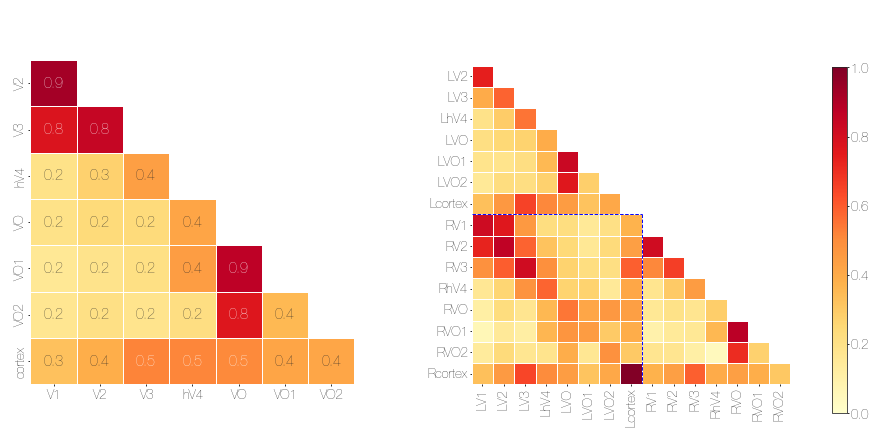

In [41]:
fig, axes = plt.subplots(1,2, figsize=(7, 4), gridspec_kw={"width_ratios": [1.09,1]})

heatmap_rc = {'text.color': 'black',
              'axes.labelcolor': 'black',
              'axes.labelpad': 1,
              'xtick.major.pad': 1,
              'ytick.major.pad': 1,
              'axes.labelweight': 'light',
              'axes.linewidth':0.4,
              'xtick.major.width':0.4,
              'ytick.major.width':0.4,
              'xtick.major.size':1,
              'ytick.major.size':1,
              'xtick.color': 'black',
              'ytick.color': 'black',
              'xtick.labelcolor': 'black',
              'ytick.labelcolor': 'black',
              'font.family': 'helveticaneue',
              'font.weight': 'light',
              'font.size' : 10,
              'figure.dpi': 72*3,
              'savefig.dpi': 72*4,
              }


corr_matrix, mask = vis.get_correlation_matrix(ax1_plot_df)
ax1 = vis.heatmap_surface_area(corr_matrix, font_scale=0.9, 
                         mask=mask, ax=axes[0],
                         annot=True, cbar=False,
                         boundary_line=None, rc=heatmap_rc)

corr_matrix, mask = vis.get_correlation_matrix(ax2_plot_df)
ax2 = vis.heatmap_surface_area(corr_matrix, ax=axes[1],
                         mask=mask, font_scale=0.6, 
                         annot=False, rc=heatmap_rc, cbar=False,
                         boundary_line=len(roi_list)+1)

# Get current position of the subplot
pos0 = axes[0].get_position()  
pos1 = axes[1].get_position()


# Modify the position: [left, bottom, width, height]
axes[0].set_position([pos0.x0, pos1.y0, pos0.width, pos0.height])

# Add colorbar in a new axes after plotting
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.6])  # [left, bottom, width, height]
fig.colorbar(ax1.collections[0], cax=cbar_ax, )

fig.savefig(os.path.join(fig_dir, 'corr3.svg'), bbox_inches='tight', transparent=True)

#utils.save_fig(os.path.join(fig_dir, 'corr.svg'), fig)
#utils.save_fig(os.path.join(fig_dir, 'corr.png'), fig)


In [40]:
# leaving out VO  
# noise ceiling (from anna and helen) 
# test * retest = sqrt(.9*.8) -> noise ceiling 
# diagonal line can be noise ceiling values. either we just show them / correct them 
# pick two researchers and do this for every combination. (test-retest) 